# 01 - Data Exploration

Exploring the Construction Site Safety dataset before training.
- Split statistics
- Class distribution
- Sample images with annotations
- Bounding box size analysis


In [9]:
import os
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Detect environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATASET_DIR = Path('/content/css-data')
else:
    DATASET_DIR = Path(r"D:\Interview\SecondRoundOriginalgit\construction-safety-monitor\data\dataset\css-data")

CLASS_NAMES = {
    0: "Hardhat",       1: "Mask",          2: "NO-Hardhat",
    3: "NO-Mask",       4: "NO-Safety Vest", 5: "Person",
    6: "Safety Cone",   7: "Safety Vest",   8: "machinery",
    9: "vehicle"
}
CLASS_COLORS = {
    0: "#00CC00", 1: "#00CC00", 2: "#FF0000",
    3: "#FF0000", 4: "#FF0000", 5: "#FF8C00",
    6: "#FFFF00", 7: "#00CC00", 8: "#888888", 9: "#888888"
}

print(f"Running in Colab : {IN_COLAB}")
print(f"Dataset path     : {DATASET_DIR}")
print(f"Exists           : {DATASET_DIR.exists()}")


Running in Colab : True
Dataset path     : /content/css-data
Exists           : False


In [13]:
if IN_COLAB:
    import zipfile
    from google.colab import drive
    drive.mount('/content/drive')

    ZIP_PATH = Path('/content/drive/MyDrive/Task/archive.zip')
    
    if not DATASET_DIR.exists():
        print("Unzipping archive.zip ...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall('/content/')
        print("Done!")
    
    print(f"Dataset exists: {DATASET_DIR.exists()}")
else:
    print("Running locally - no unzip needed")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping archive.zip ...
Done!
Dataset exists: True


## 1. Split Statistics

How many images in each split?

In [14]:
for split in ["train", "valid", "test"]:
    img_dir = DATASET_DIR / split / "images"
    lbl_dir = DATASET_DIR / split / "labels"
    if img_dir.exists():
        n_img = len(list(img_dir.glob("*")))
        n_lbl = len(list(lbl_dir.glob("*.txt")))
        print(f"{split:>6}: {n_img:>5} images | {n_lbl:>5} label files")


 train:  2605 images |  2605 label files
 valid:   114 images |   114 label files
  test:    82 images |    82 label files


## 2. Class Distribution

The dataset uses **dual-class labelling**:
- Labels both `Hardhat` AND `NO-Hardhat`
- This lets the model actively detect missing PPE, not just infer it


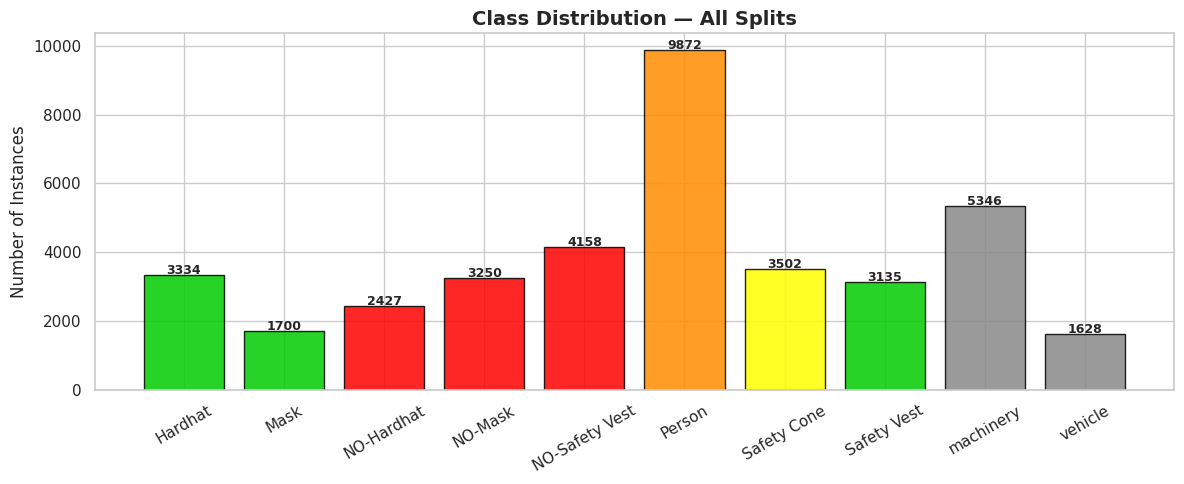


Class counts:
  Hardhat             : 3334
  Mask                : 1700
  NO-Hardhat          : 2427
  NO-Mask             : 3250
  NO-Safety Vest      : 4158
  Person              : 9872
  Safety Cone         : 3502
  Safety Vest         : 3135
  machinery           : 5346
  vehicle             : 1628


In [15]:
class_counts = Counter()

for split in ["train", "valid", "test"]:
    lbl_dir = DATASET_DIR / split / "labels"
    if not lbl_dir.exists():
        continue
    for lbl_file in lbl_dir.glob("*.txt"):
        for line in lbl_file.read_text().strip().split("\n"):
            if line.strip():
                cls_id = int(line.strip().split()[0])
                class_counts[cls_id] += 1

ids    = sorted(class_counts.keys())
counts = [class_counts[i] for i in ids]
names  = [CLASS_NAMES[i] for i in ids]
colors = [CLASS_COLORS[i] for i in ids]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, counts, color=colors, edgecolor="black", alpha=0.85)
ax.set_title("Class Distribution — All Splits", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Instances")
ax.tick_params(axis="x", rotation=30)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            str(count), ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nClass counts:")
for name, count in zip(names, counts):
    print(f"  {name:<20}: {count}")


## 3. Sample Images with Annotations

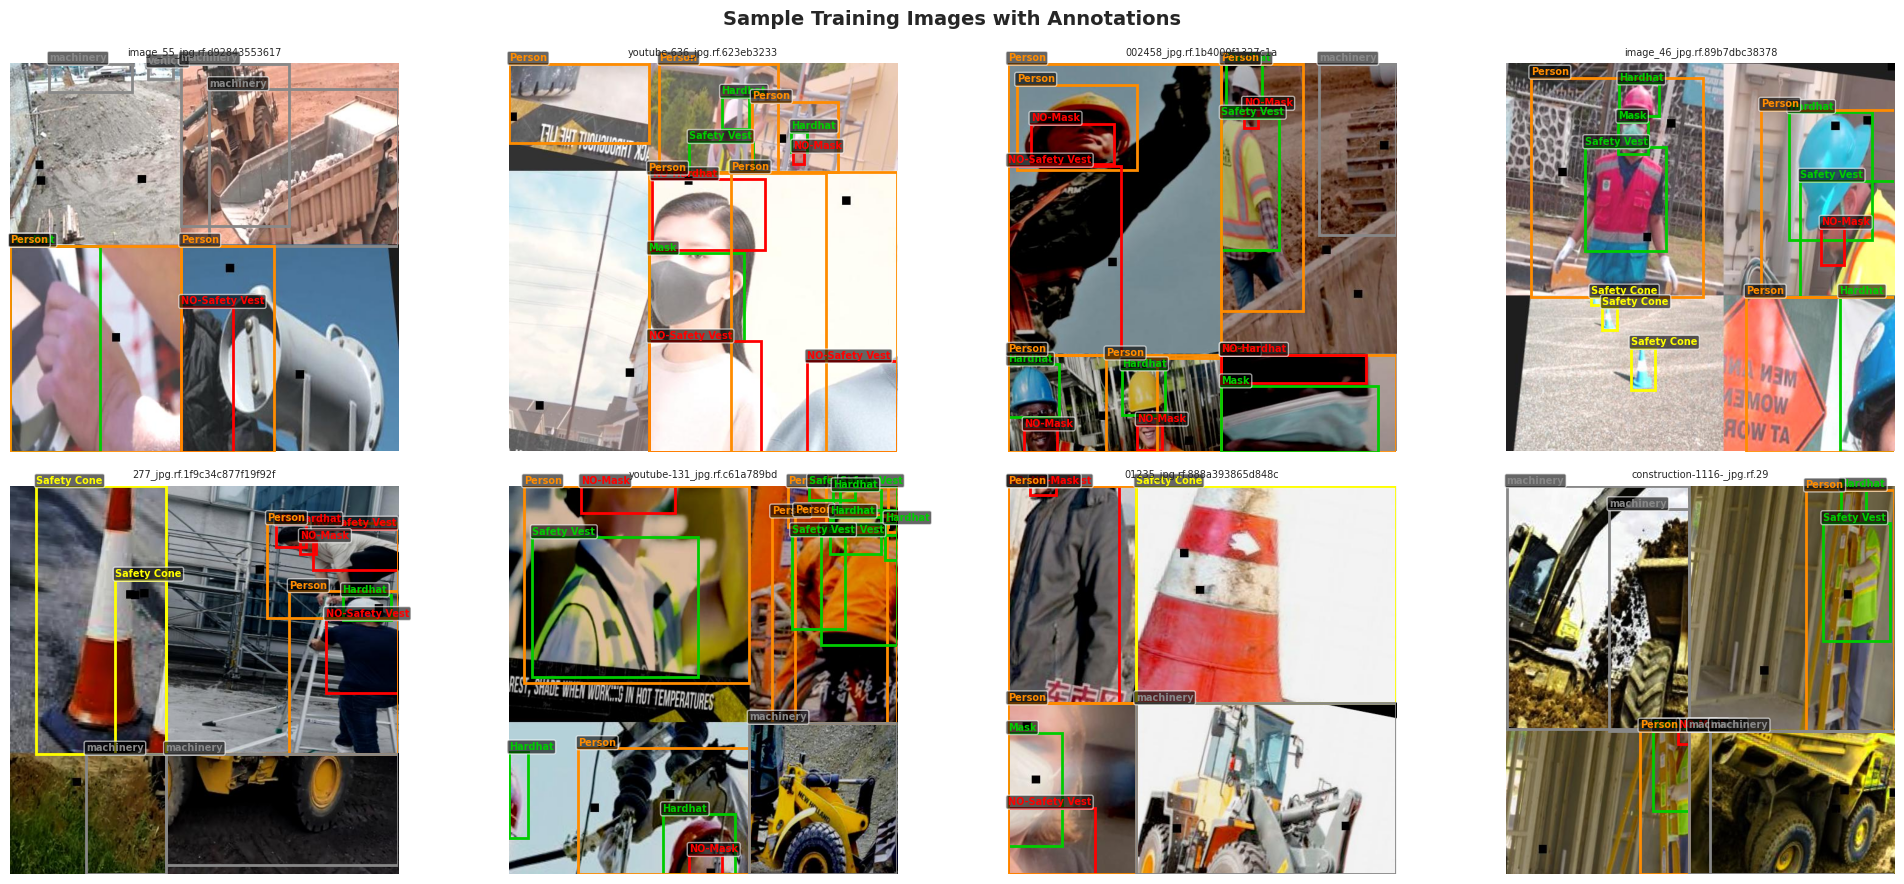

In [16]:
def draw_annotated(img_path, lbl_path, ax):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)

    if lbl_path.exists():
        for line in lbl_path.read_text().strip().split("\n"):
            if not line.strip():
                continue
            parts  = line.strip().split()
            cls_id = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            color = CLASS_COLORS.get(cls_id, "#FFFFFF")
            rect  = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, CLASS_NAMES.get(cls_id, "?"),
                    color=color, fontsize=7, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2",
                              facecolor="black", alpha=0.6))
    ax.axis("off")
    ax.set_title(img_path.name[:28], fontsize=7)

train_imgs = list((DATASET_DIR / "train" / "images").glob("*"))
samples    = random.sample(train_imgs, min(8, len(train_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, img_path in zip(axes.flat, samples):
    lbl_path = img_path.parent.parent / "labels" / (img_path.stem + ".txt")
    draw_annotated(img_path, lbl_path, ax)

plt.suptitle("Sample Training Images with Annotations",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Bounding Box Size Analysis

Small objects = distant workers = harder to detect.


Small  (area <  1%): 16852  (43.9%)
Medium (area 1%-5%):  7803  (20.3%)
Large  (area >  5%): 13697  (35.7%)


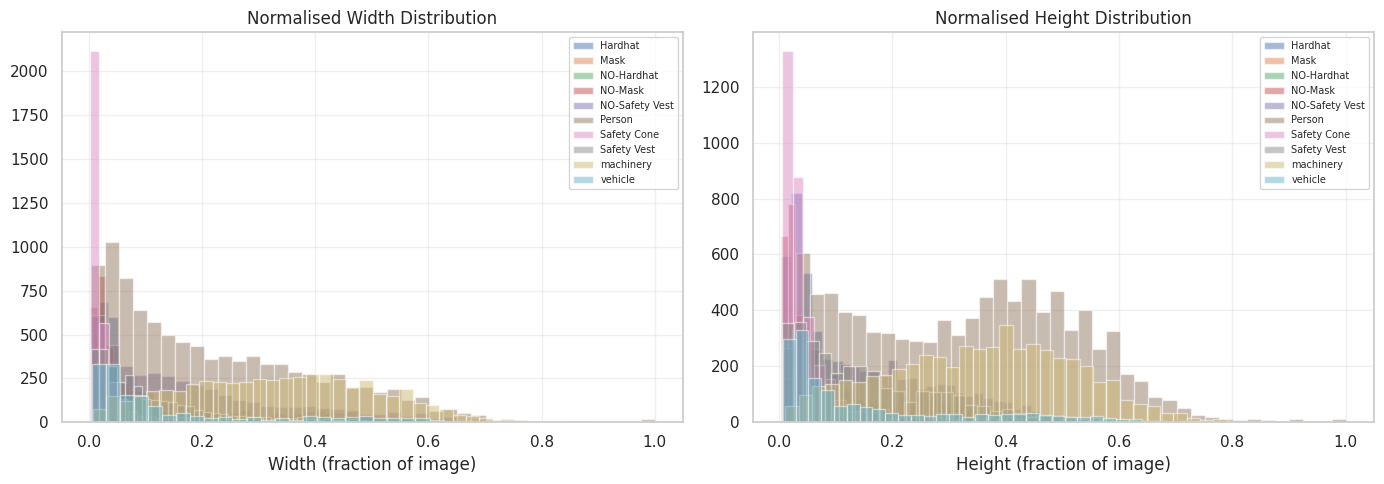

In [17]:
bbox_sizes = []

for split in ["train", "valid", "test"]:
    lbl_dir = DATASET_DIR / split / "labels"
    if not lbl_dir.exists():
        continue
    for lbl_file in lbl_dir.glob("*.txt"):
        for line in lbl_file.read_text().strip().split("\n"):
            if line.strip():
                parts = line.strip().split()
                if len(parts) == 5:
                    bbox_sizes.append(
                        (int(parts[0]), float(parts[3]), float(parts[4]))
                    )

arr   = np.array(bbox_sizes)
areas = arr[:, 1] * arr[:, 2]
total = len(areas)

print(f"Small  (area <  1%): {(areas < 0.01).sum():>5}  ({(areas < 0.01).sum()/total*100:.1f}%)")
print(f"Medium (area 1%-5%): {((areas >= 0.01) & (areas < 0.05)).sum():>5}  ({((areas >= 0.01) & (areas < 0.05)).sum()/total*100:.1f}%)")
print(f"Large  (area >  5%): {(areas >= 0.05).sum():>5}  ({(areas >= 0.05).sum()/total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cls_id in sorted(set(arr[:, 0].astype(int))):
    mask = arr[:, 0] == cls_id
    axes[0].hist(arr[mask, 1], bins=40, alpha=0.5,
                 label=CLASS_NAMES.get(int(cls_id)))
    axes[1].hist(arr[mask, 2], bins=40, alpha=0.5,
                 label=CLASS_NAMES.get(int(cls_id)))

axes[0].set_title("Normalised Width Distribution")
axes[0].set_xlabel("Width (fraction of image)")
axes[1].set_title("Normalised Height Distribution")
axes[1].set_xlabel("Height (fraction of image)")
for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Key Observations

- **2,801 total images** — 2605 train / 114 valid / 82 test
- **Dual-class labelling** — both `Hardhat` AND `NO-Hardhat` annotated. This is what makes violation detection reliable instead of guessing.
- **Person** has the most instances — makes sense as every scene has workers.
- **Small objects** are common — distant workers will be the model's hardest challenge.
- **24 empty label files** — background/negative examples, help reduce false positives.
- **No data leakage** — train/valid/test filenames are all unique.
